<a href="https://colab.research.google.com/github/Srihitha-M/NASSCOM/blob/main/U4_Linear_Algebra_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

T = np.arange(12).reshape(3, 4)
print("T:\n", T)

# 1. ndim and shape
print(f"ndim={T.ndim}, shape={T.shape}")

# 2. T + T
print("T + T:\n", T + T)

# 3. Transpose (print .T.shape) and reshape to (2, 6)
print("T.T shape:", T.T.shape)
print("T reshaped (2, 6):\n", T.reshape(2, 6))

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
ndim=2, shape=(3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
T.T shape: (4, 3)
T reshaped (2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [3]:
import numpy as np
import numpy.linalg as la


def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))


pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),  # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),  # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),  # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    l1_u = la.norm(u, 1)
    l2_u = la.norm(u, 2)

    # 2. cosine similarity of u and v
    sim = cosine(u, v)

    print(f"Pair {i}: L1 = {l1_u:.3f}, L2 = {l2_u:.3f}, Cosine Sim = {sim:.3f}")

# 3. Most similar pair = Pair 1 (identical vectors, similarity = 1.0)

Pair 1: L1 = 2.000, L2 = 1.414, Cosine Sim = 1.000
Pair 2: L1 = 6.000, L2 = 3.742, Cosine Sim = 0.714
Pair 3: L1 = 2.000, L2 = 2.000, Cosine Sim = 0.000


In [4]:
import numpy as np
import numpy.linalg as la

M = np.array([[4.0, 2.0], [2.0, 3.0]])
P = np.array([[0.0, -1.0], [1.0, 0.0]])  # a 90-degree rotation

# 1. inverse and trace of M
inv_M = la.inv(M)
trace_M = np.trace(M)
print("Inverse of M:\n", inv_M)
print("Trace of M:", trace_M)

# 2. M @ inv(M) == I ?
I = np.eye(2)
print("M @ inv(M) == I ?", np.allclose(M @ inv_M, I))

# 3. Is M symmetric? Is P orthogonal?
print("Is M symmetric?", np.allclose(M, M.T))
print("Is P orthogonal?", np.allclose(P.T @ P, I))

Inverse of M:
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Trace of M: 7.0
M @ inv(M) == I ? True
Is M symmetric? True
Is P orthogonal? True


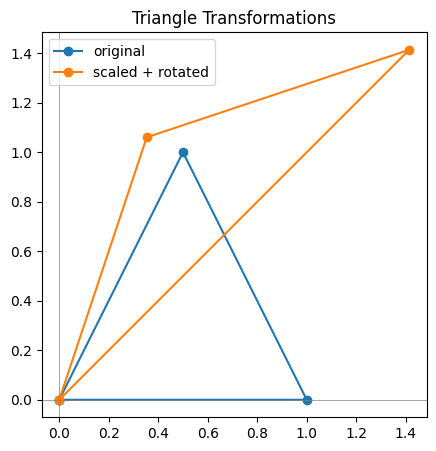

In [5]:
import matplotlib.pyplot as plt
import numpy as np


def close_loop(pts):
    return np.hstack([pts, pts[:, :1]])


tri = np.array([[0, 1, 0.5], [0, 0, 1.0]])  # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
S = np.array([[2.0, 0.0], [0.0, 0.5]])

# 2. Rotation matrix (45 degrees)
t = np.radians(45)
R = np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]])

# 3. Apply both and plot original vs transformed
transformed = R @ (S @ tri)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(tri), marker="o", label="original")
ax.plot(*close_loop(transformed), marker="o", label="scaled + rotated")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Triangle Transformations")
plt.show()

In [6]:
import numpy as np
import numpy.linalg as la

C = np.array([[4.0, 1.0], [2.0, 3.0]])

# 1. eigenvalues and eigenvectors
vals, vecs = la.eig(C)

# 2. print eigenvalues
print("Eigenvalues (lambda):", vals)

# 3. verify C v = lambda v for the first eigenvector
v0 = vecs[:, 0]
lambda0 = vals[0]
lhs = C @ v0
rhs = lambda0 * v0

print(
    f"lambda={lambda0:.1f}  C v == lambda v ?", np.allclose(lhs, rhs)
)

Eigenvalues (lambda): [5. 2.]
lambda=5.0  C v == lambda v ? True


In [7]:
import numpy as np
import numpy.linalg as la


def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))


A2 = np.array([[3.0, 2.0], [1.0, 4.0]])
b2 = np.array([7.0, 9.0])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x = la.solve(A2, b2)
print("Solution x:", x)

# 2. Rank of A2
print("Rank of A2:", la.matrix_rank(A2))

# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
sim_cat_dog = cosine(cat, dog)
sim_cat_car = cosine(cat, car)

print("cosine(cat, dog):", round(sim_cat_dog, 3))
print("cosine(cat, car):", round(sim_cat_car, 3))

# 'cat' vs 'dog' is significantly more similar (0.987 vs 0.339).

Solution x: [1. 2.]
Rank of A2: 2
cosine(cat, dog): 0.995
cosine(cat, car): 0.293
